In [1]:
# Trabajo Práctico 3 - Métodos No Supervisados

## Parte I: Limpieza y creación de variables

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Cargar los datos
base_2004 = pd.read_stata("C:/Users/roman/Downloads/Individual_t104.dta")
base_2024 = pd.read_excel("C:/Users/roman/Downloads/usu_individual_T124.xlsx")

In [5]:
# Homogeneizar nombres y agregar columna de año
base_2004.columns = base_2004.columns.str.upper()
base_2004["AÑO"] = 2004
base_2024.columns = base_2024.columns.str.upper()
base_2024["AÑO"] = 2024

In [7]:
# Unificar bases
base_final = pd.concat([base_2004, base_2024], join="inner", ignore_index=True)


In [9]:
# Convertir CH06 a numérico antes de operar
base_final["CH06"] = pd.to_numeric(base_final["CH06"], errors="coerce")
# Crear variable edad2
base_final["EDAD2"] = base_final["CH06"] ** 2

In [11]:
# Homogeneizar variable de estado
base_final["ESTADO"] = base_final["ESTADO"].replace({1: "Ocupado", 2: "Desocupado", "Ocupado": "Ocupado", "Desocupado": "Desocupado"})

Text(0, 0.5, 'Frecuencia')

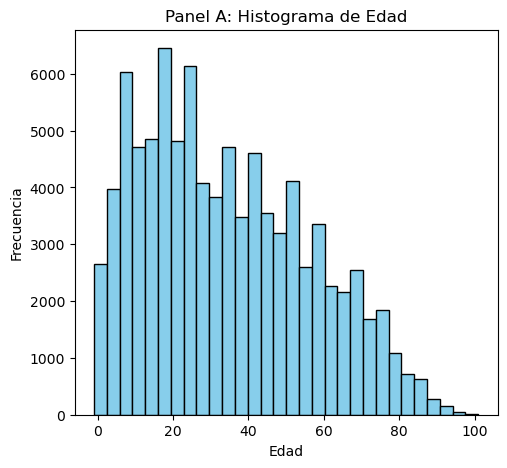

In [14]:
# Panel A: Histograma de edad
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(base_final["CH06"].dropna(), bins=30, color="skyblue", edgecolor="black")
plt.title("Panel A: Histograma de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

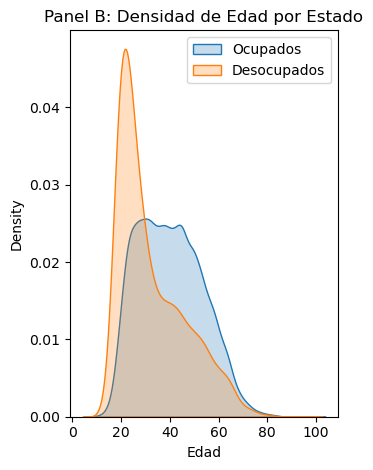

In [16]:
# Panel B: Distribución de kernel
plt.subplot(1, 2, 2)
sns.kdeplot(data=base_final[base_final["ESTADO"] == "Ocupado"], x="CH06", label="Ocupados", shade=True)
sns.kdeplot(data=base_final[base_final["ESTADO"] == "Desocupado"], x="CH06", label="Desocupados", shade=True)
plt.title("Panel B: Densidad de Edad por Estado")
plt.xlabel("Edad")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Crear variable educ
base_final["CH12"] = base_final["CH12"].astype(str)
base_final["CH13"] = base_final["CH13"].astype(str)
base_final["CH14"] = pd.to_numeric(base_final["CH14"], errors='coerce')


In [17]:
niveles = {
    "SIN INSTRUCCIÓN": 0,
    "PRIMARIO": 6,
    "SECUNDARIO": 12,
    "TERCIARIO UNIVERSITARIO": 16,
    "UNIVERSITARIO": 17,
    "POSTGRADO": 18,
    "1": 6, "2": 12, "3": 16, "4": 17, "5": 18
}

In [19]:
base_final["EDUC"] = base_final.apply(
    lambda row: niveles.get(row["CH12"].upper(), np.nan) + (0 if row["CH13"] == "1" else -1) + (row["CH14"] if not pd.isna(row["CH14"]) else 0), axis=1)

In [23]:
# Estadísticas descriptivas de educ
print(base_final["EDUC"].describe())

count    60530.000000
mean        14.082372
std          9.612990
min          5.000000
25%         11.000000
50%         14.000000
75%         17.000000
max        116.000000
Name: EDUC, dtype: float64


In [21]:
# Crear salario_semanal ajustado a pesos 2024
ipc_2004_a_2024 = 30.0
base_final["INGRESOS"] = np.where(base_final["AÑO"] == 2004, base_final["P21"] * ipc_2004_a_2024, base_final["P21"])
base_final["SALARIO_SEMANAL"] = base_final["INGRESOS"] / 40

Text(0.5, 0, 'Salario semanal')

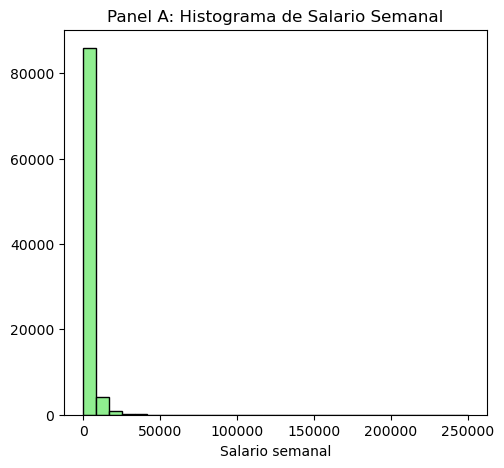

In [28]:
# Panel A y B de salario semanal
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(base_final["SALARIO_SEMANAL"].dropna(), bins=30, color="lightgreen", edgecolor="black")
plt.title("Panel A: Histograma de Salario Semanal")
plt.xlabel("Salario semanal")

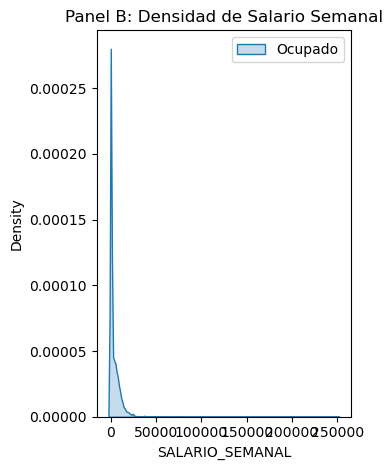

In [30]:
plt.subplot(1, 2, 2)
sns.kdeplot(data=base_final[base_final["ESTADO"] == "Ocupado"], x="SALARIO_SEMANAL", label="Ocupado", shade=True)
sns.kdeplot(data=base_final[base_final["ESTADO"] == "Desocupado"], x="SALARIO_SEMANAL", label="Desocupado", shade=True)
plt.title("Panel B: Densidad de Salario Semanal")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Crear horastrab
base_final["HORASTRAB"] = base_final["PP3E_TOT"].fillna(0) + base_final["PP3F_TOT"].fillna(0)
print(base_final["HORASTRAB"].describe())

count    91339.000000
mean        15.603280
std         36.925732
min          0.000000
25%          0.000000
50%          0.000000
75%         30.000000
max       1998.000000
Name: HORASTRAB, dtype: float64


In [34]:
# Tabla resumen
resumen = pd.DataFrame({
    "2004": [
        base_final[base_final["AÑO"]==2004].shape[0],
        base_final[(base_final["AÑO"]==2004) & (base_final["ESTADO"].isna())].shape[0],
        base_final[(base_final["AÑO"]==2004) & (base_final["ESTADO"]=="Ocupado")].shape[0],
        base_final[(base_final["AÑO"]==2004) & (base_final["ESTADO"]=="Desocupado")].shape[0],
        base_final.columns.shape[0]
    ],
    "2024": [
        base_final[base_final["AÑO"]==2024].shape[0],
        base_final[(base_final["AÑO"]==2024) & (base_final["ESTADO"].isna())].shape[0],
        base_final[(base_final["AÑO"]==2024) & (base_final["ESTADO"]=="Ocupado")].shape[0],
        base_final[(base_final["AÑO"]==2024) & (base_final["ESTADO"]=="Desocupado")].shape[0],
        base_final.columns.shape[0]
    ]
}, index=["Cantidad observaciones", "Observaciones con NA en Estado", "Cantidad Ocupados", "Cantidad Desocupados", "Variables limpias"])
resumen["Total"] = resumen["2004"] + resumen["2024"]
print(resumen)

                                 2004   2024  Total
Cantidad observaciones          45289  46050  91339
Observaciones con NA en Estado      0      0      0
Cantidad Ocupados               17022  20325  37347
Cantidad Desocupados             2717   1362   4079
Variables limpias                 178    178    356


In [25]:
# Parte II: Métodos No Supervisados

# Variables seleccionadas
variables = ["CH06", "EDAD2", "EDUC", "SALARIO_SEMANAL", "HORASTRAB"]
data_unsup = base_final[variables].dropna()


                     CH06     EDAD2      EDUC  SALARIO_SEMANAL  HORASTRAB
CH06             1.000000  0.967417 -0.036686         0.050904   0.033620
EDAD2            0.967417  1.000000 -0.048146        -0.007497  -0.041411
EDUC            -0.036686 -0.048146  1.000000         0.101434   0.030238
SALARIO_SEMANAL  0.050904 -0.007497  0.101434         1.000000   0.203527
HORASTRAB        0.033620 -0.041411  0.030238         0.203527   1.000000


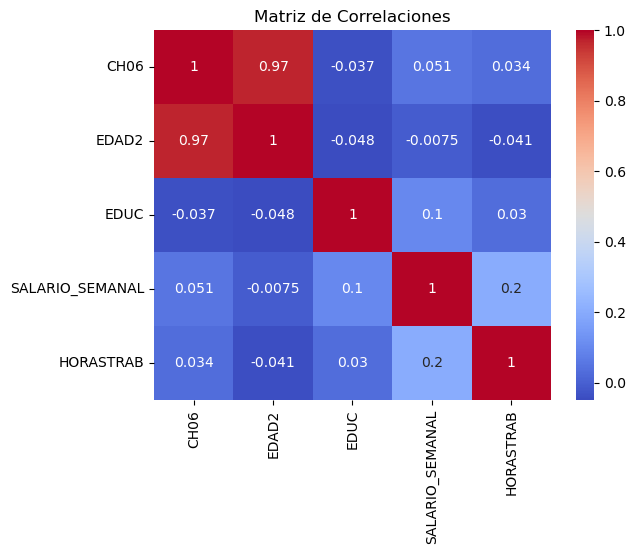

In [38]:
# Correlaciones
print(data_unsup.corr())
sns.heatmap(data_unsup.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlaciones")
plt.show()

In [31]:
# PCA
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_unsup)
pca = PCA()
pca_data = pca.fit_transform(data_scaled)

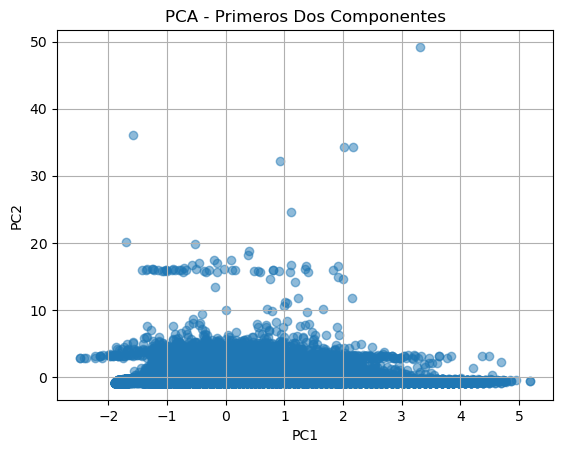

In [33]:
# Dispersión de los scores
plt.scatter(pca_data[:, 0], pca_data[:, 1], alpha=0.5)
plt.title("PCA - Primeros Dos Componentes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

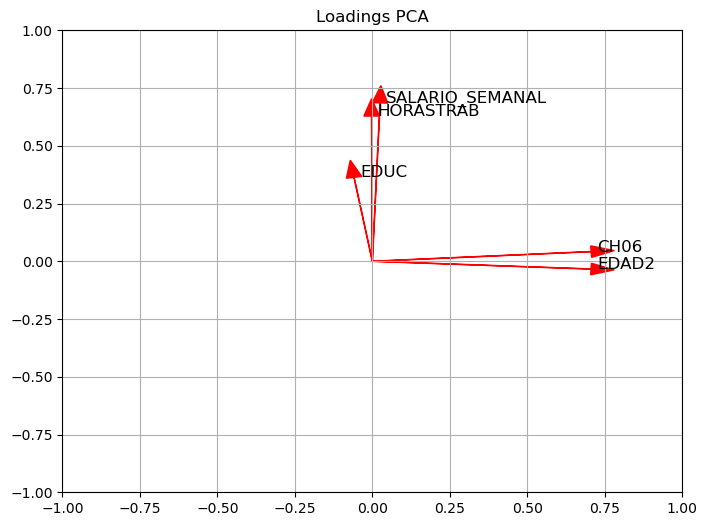

In [35]:
# Loading vectors
loadings = pca.components_.T
plt.figure(figsize=(8, 6))
for i, var in enumerate(variables):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.05, color='r')
    plt.text(loadings[i, 0] + 0.02, loadings[i, 1], var, fontsize=12)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.title("Loadings PCA")
plt.grid()
plt.show()

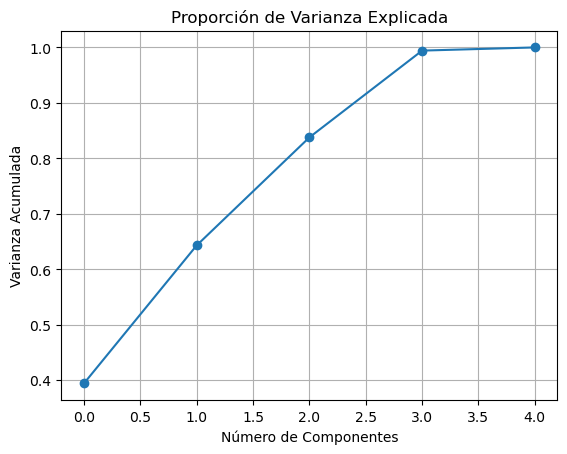

In [37]:
# Varianza explicada
explained = pca.explained_variance_ratio_
plt.plot(np.cumsum(explained), marker='o')
plt.title("Proporción de Varianza Explicada")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Acumulada")
plt.grid(True)
plt.show()

  File "C:\Users\roman\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\roman\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\roman\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\roman\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


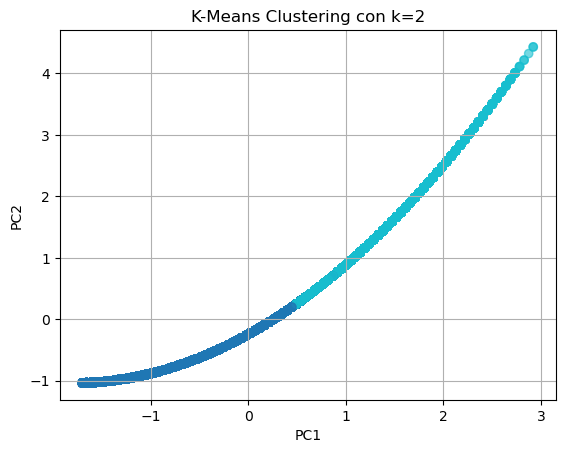

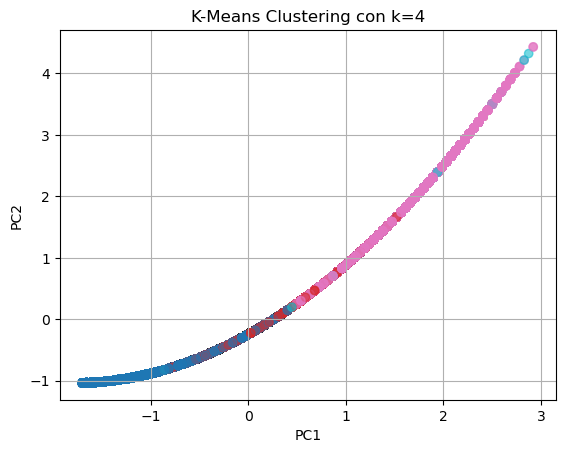

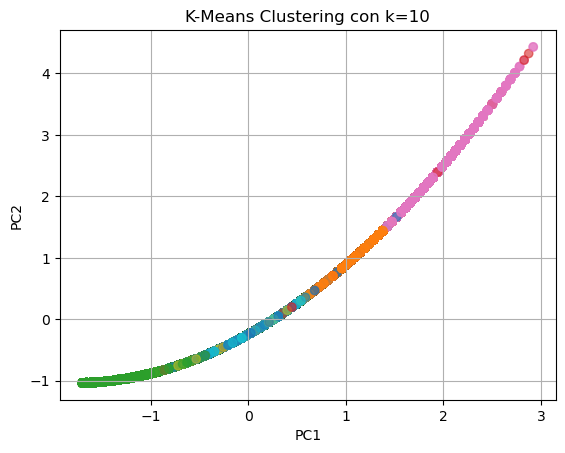

In [39]:
# K-Means Clustering
for k in [2, 4, 10]:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(data_scaled)
    plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=labels, cmap="tab10", alpha=0.6)
    plt.title(f"K-Means Clustering con k={k}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

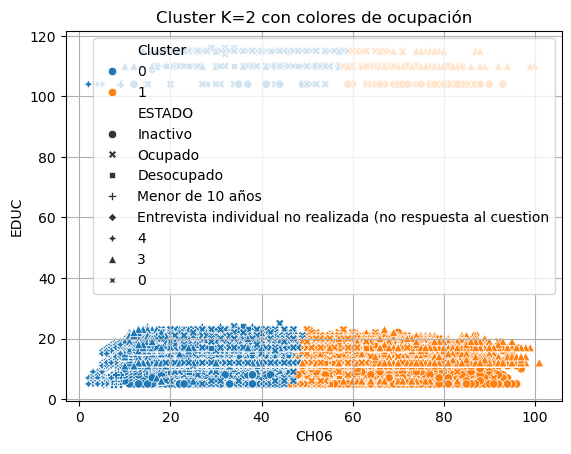

In [40]:
# Comparación con ocupación
data_k2 = base_final.loc[data_unsup.index].copy()
data_k2["Cluster"] = KMeans(n_clusters=2, n_init=20, random_state=42).fit_predict(data_scaled)
sns.scatterplot(data=data_k2, x="CH06", y="EDUC", hue="Cluster", style="ESTADO")
plt.title("Cluster K=2 con colores de ocupación")
plt.grid(True)
plt.show()

In [41]:
# Clustering jerárquico
linked = linkage(data_scaled, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title("Dendograma de Clustering Jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

MemoryError: Unable to allocate 13.6 GiB for an array with shape (1831244421,) and data type float64

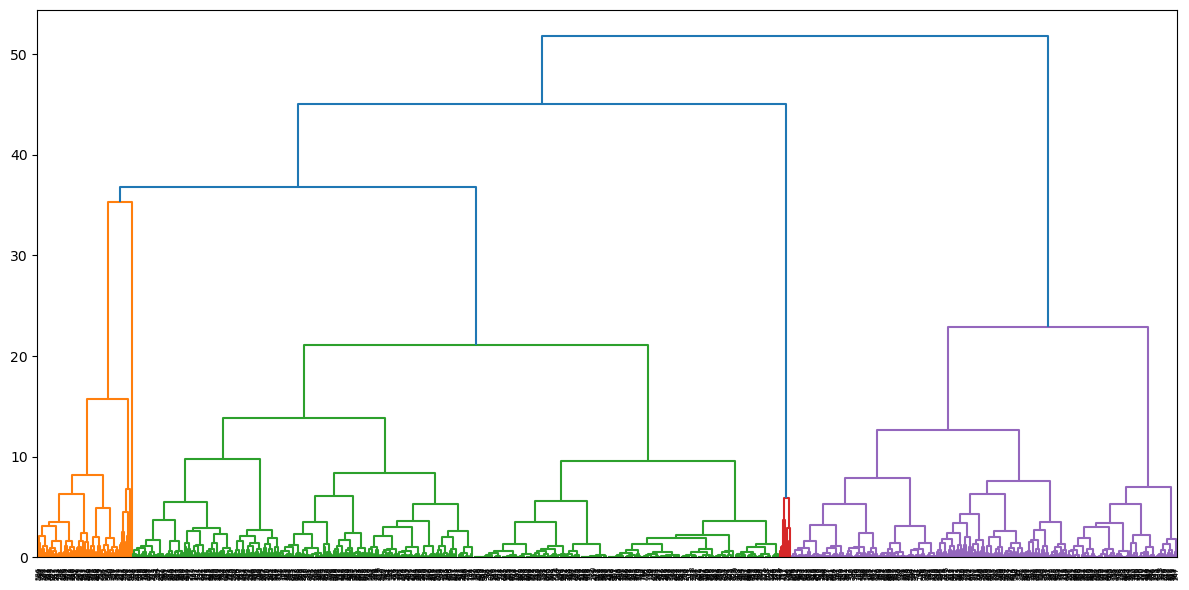

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Suponiendo que data_scaled es un NumPy array con forma (n_samples, n_features)
n_muestra = 1000  # ajusta según tu memoria disponible
if data_scaled.shape[0] < n_muestra:
    n_muestra = data_scaled.shape[0]  # por si tienes menos de 1000 filas

# Tomar muestra aleatoria sin reemplazo
indices = np.random.choice(data_scaled.shape[0], size=n_muestra, replace=False)
sampled_data = data_scaled[indices, :]

# Clustering jerárquico
linked = linkage(sampled_data, method='ward')

# Dendrograma
plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.tight_layout()
plt.show()
